In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [9]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [11]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [12]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        n0 = int(0.10 * n)
        nk = int(0.20 * n)
        nf = n - n0 - nk

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        return torch.cat([t_full, t_start, t_kink], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t


    # ---- causal training grid (Wang, Sankaran, Perdikaris 2024) ----------
    def causal_time_grid(self, n_t, t_lo=0.0, t_hi=None, jitter=True):
        # Sorted time grid t_1 < ... < t_Nt over (t_lo, t_hi]. linspace cells with
        # intra-cell jitter keep strict ordering (needed for the causal cumulative
        # sum). The left edge t_lo is the IC anchor (handled in causal_pde_loss).
        te = self.case.t_end_star if t_hi is None else t_hi
        edges = torch.linspace(t_lo, te, n_t + 1, device=self.device, dtype=self.dtype)
        left = edges[:-1]
        width = float(edges[1] - edges[0])
        if jitter:
            u = torch.rand(n_t, device=self.device, dtype=self.dtype)
        else:
            u = torch.full((n_t,), 0.5, device=self.device, dtype=self.dtype)
        t = left + u * width
        return t.reshape(-1, 1)

    def causal_space(self, n_t, n_z):
        # For each of n_t times, n_z spatial points spanning the RESOLVABLE
        # INTERIOR [3a, 1-3a]. The near-face zones [0,3a] and [1-3a,1] are
        # EXCLUDED from the pointwise PDE residual on purpose: that is where the
        # inlet/outlet LOCAL pressure losses live as a near-discontinuous jump a
        # smooth net cannot resolve. Forcing the momentum PDE there pins R_mom at
        # an irreducible ~0.28 floor (the omitted local-loss term), and that floor
        # keeps the causal cumulative Sum L_r from ever shrinking behind the front
        # -> the front can never detach from t=0 (causality stays off). The faces
        # are still enforced by the imposed-dp BC and the integral momentum keeper
        # (which integrates over the FULL channel). With the faces masked out here,
        # L_r CAN reach ~0 on converged times -- the precondition for a real front.
        a = self.alpha
        lo, hi = 3.0 * a, 1.0 - 3.0 * a
        w = 3.0 * a                      # edge band just inside the mask
        n_edge = max(1, round(0.25 * n_z))
        n_mid = n_z - 2 * n_edge

        def block(n, z0, z1):
            return z0 + (z1 - z0) * torch.rand(
                n_t, n, device=self.device, dtype=self.dtype,
            )

        z_lo = block(n_edge, lo, lo + w)         # [3a, 6a]
        z_mid = block(n_mid, lo + w, hi - w)     # [6a, 1-6a]
        z_hi = block(n_edge, hi - w, hi)         # [1-6a, 1-3a]
        return torch.cat([z_lo, z_mid, z_hi], dim=1)


In [13]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


In [14]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.causal_pde_loss(
            self.sampler, self.weights, eps, t_lo, t_hi, ic_spec,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: (float(value.detach().cpu()) if torch.is_tensor(value) else float(value))
            for key, value in logs.items()
        }


class StitchedModel(nn.Module):
    # Routes (z, t) to the window model that owns t, so the marched solution acts
    # as one model over [0, t_end] for all the diagnostic cells. Each submodel is
    # evaluated on all points and masked (differentiable; cheap at diagnostic
    # sizes). Windows partition time as [lo, hi) except the last, which is [lo, hi].
    def __init__(self, windows, t_end_star):
        super().__init__()
        self.submodels = nn.ModuleList([m for (_, _, m) in windows])
        self.bounds = [(float(lo), float(hi)) for (lo, hi, _) in windows]
        self.t_end_star = float(t_end_star)

    def forward(self, z, t):
        G = torch.zeros_like(z)
        H = torch.zeros_like(z)
        P = torch.zeros_like(z)
        n = len(self.bounds)
        for j, ((lo, hi), m) in enumerate(zip(self.bounds, self.submodels)):
            mask = (t >= lo) & (t < hi) if j < n - 1 else (t >= lo) & (t <= hi)
            sel = mask.to(z.dtype)
            g, h, pp = m(z, t)
            G = G + sel * g
            H = H + sel * h
            P = P + sel * pp
        return G, H, P



In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

model = SmoothPINN(
    t_end_star=case.t_end_star,
    width=128,
    depth=6,
    activation="tanh",
).to(device=device, dtype=dtype)

# Data-parallel across 4 CUDA devices [0, 1, 2, 3]: each step's collocation batch
# is split over the GPUs, the model is replicated, outputs gathered on cuda:0.
# NOTE: the PINN's second-order autograd (create_graph in d()) runs through
# DataParallel's scatter/gather -- works on recent torch but is memory-heavy; if
# it errors, DDP (multi-process) is the robust route.
DEVICE_IDS = [0, 1, 2, 3]
if torch.cuda.is_available() and torch.cuda.device_count() >= len(DEVICE_IDS):
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
    print(f"DataParallel across cuda {DEVICE_IDS} ({torch.cuda.device_count()} GPUs visible)")
else:
    print(f"single device {device} (need >= {len(DEVICE_IDS)} CUDA GPUs for tp=4)")

sampler = Sampler(
    case=case,
    device=device,
    dtype=dtype,
    alpha=0.02,
)

physics = Physics(
    model=model,
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)

weights = LossWeights(
    mass=2.0,
    mom=0.25,
    energy=0.5,
    causal_ic=1000.0,
    causal_bc=30.0,
    mom_integral=20.0,
    energy_integral=20.0,
    mass_integral=20.0,
    Nt=96,
    Nz_pde=256,
    Nz_keeper=257,
)

# Causal annealing (Wang+2024, Algorithm 1): sweep eps low->high, run S steps per
# eps, jump to the next eps once the whole domain has converged (min_i w_i > delta).
# BITING schedule: with the near-face PDE floor masked out (causal_space is now
# interior-only) L_r reaches ~0 on converged times, so the cumulative shrinks
# behind the front and eps>=1 GATES instead of collapsing. 1e-2 warms up,
# 1e-1 grades, 1e0/1e1 push the front across the domain. Watch the causal-front
# plot: w_i(t) should be a MOVING STEP, not flat 1.  (was: soft [5e-4..5e-3])
# graded-but-alive and the keepers converge on all times. Drive the residual down
# FIRST; revisit high eps only once L_r drops well below ~1e-2.
eps_schedule = [1e-2, 1e-1, 1e0, 1e1]
steps_per_eps = 10000     # <-- main cost knob (you run the training)
causal_delta = 0.99
LR = 3e-4                # 3e-4 gave NO residual gain (tested): pde plateaus ~0.089 either way

trainer = Trainer(
    model=model,
    physics=physics,
    sampler=sampler,
    weights=weights,
    lr=LR,
)


DataParallel across cuda [0, 1, 2, 3] (4 GPUs visible)


In [16]:
# Checkpoint helpers — save/load weights so diagnostics (validate, pressure_budget)
# can run without retraining (~55 min CPU otherwise).
from pathlib import Path

def save_ckpt(path):
    torch.save(
        {
            "model": (model.module if isinstance(model, nn.DataParallel) else model).state_dict(),
            "optimizer": trainer.optimizer.state_dict(),
        },
        path,
    )


def load_ckpt(path, map_location=None):
    ckpt = torch.load(path, map_location=map_location or device)
    (model.module if isinstance(model, nn.DataParallel) else model).load_state_dict(ckpt["model"])
    if "optimizer" in ckpt:
        trainer.optimizer.load_state_dict(ckpt["optimizer"])
    print(f"loaded checkpoint <- {path}")

In [17]:
# === Causal training from SCRATCH (Wang+2024, pure causal PINN) ============
# Random init, NO warm start, NO marching: one network over [0, t_end], physical
# IC at t=0, eps-annealing. The causal weights are the ONLY mechanism ordering
# time -- the front must converge from scratch before the tail switches on.
history = []
PRINT_EVERY = 200

for eps in eps_schedule:
    print(f"=== eps = {eps:g} ===")
    converged = False
    for n in range(1, steps_per_eps + 1):
        logs = trainer.step(eps)          # full domain, physical IC (defaults)
        history.append(logs)

        if n % PRINT_EVERY == 0:
            print(
                f"eps={eps:g}",
                f"step={n}",
                f"loss={logs['loss']:.3e}",
                f"w_min={logs['w_min']:.3e}",
                f"pde={logs['pde']:.3e}",
                f"bc={logs['bc']:.3e}",
                f"ic={logs['ic']:.3e}",
                f"mom_int={logs['mom_int']:.3e}",
                f"energy_int={logs['energy_int']:.3e}",
                f"mass_int={logs['mass_int']:.3e}",
            )

        if logs["w_min"] > causal_delta:
            print(f"  converged at eps={eps:g} (min w_i={logs['w_min']:.3f}) after {n} steps")
            converged = True
            break

    if not converged:
        print(f"  eps={eps:g}: budget {steps_per_eps} reached, min w_i still < {causal_delta}")

save_ckpt("v4_causal.pt")
print("saved checkpoint -> v4_causal.pt")


=== eps = 0.01 ===
eps=0.01 step=200 loss=3.998e+00 w_min=7.885e-01 pde=2.402e-01 bc=1.057e-02 ic=1.052e-03 mom_int=1.038e-02 energy_int=7.378e-02 mass_int=4.866e-02
eps=0.01 step=400 loss=2.390e+00 w_min=8.403e-01 pde=1.764e-01 bc=1.295e-02 ic=6.903e-04 mom_int=3.549e-03 energy_int=4.858e-02 mass_int=8.348e-03
eps=0.01 step=600 loss=1.990e+00 w_min=8.521e-01 pde=1.615e-01 bc=9.271e-03 ic=6.704e-04 mom_int=2.010e-03 energy_int=4.021e-02 mass_int=4.276e-03
eps=0.01 step=800 loss=2.479e+00 w_min=8.628e-01 pde=1.436e-01 bc=6.700e-03 ic=1.110e-03 mom_int=1.417e-03 energy_int=5.180e-02 mass_int=6.149e-04
eps=0.01 step=1000 loss=2.360e+00 w_min=8.523e-01 pde=1.579e-01 bc=5.054e-03 ic=9.936e-04 mom_int=1.810e-03 energy_int=4.724e-02 mass_int=6.731e-03
eps=0.01 step=1200 loss=1.571e+00 w_min=8.694e-01 pde=1.440e-01 bc=5.122e-03 ic=3.279e-04 mom_int=1.492e-03 energy_int=4.540e-02 mass_int=2.304e-03
eps=0.01 step=1400 loss=1.499e+00 w_min=8.685e-01 pde=1.456e-01 bc=4.395e-03 ic=2.922e-04 mom_int

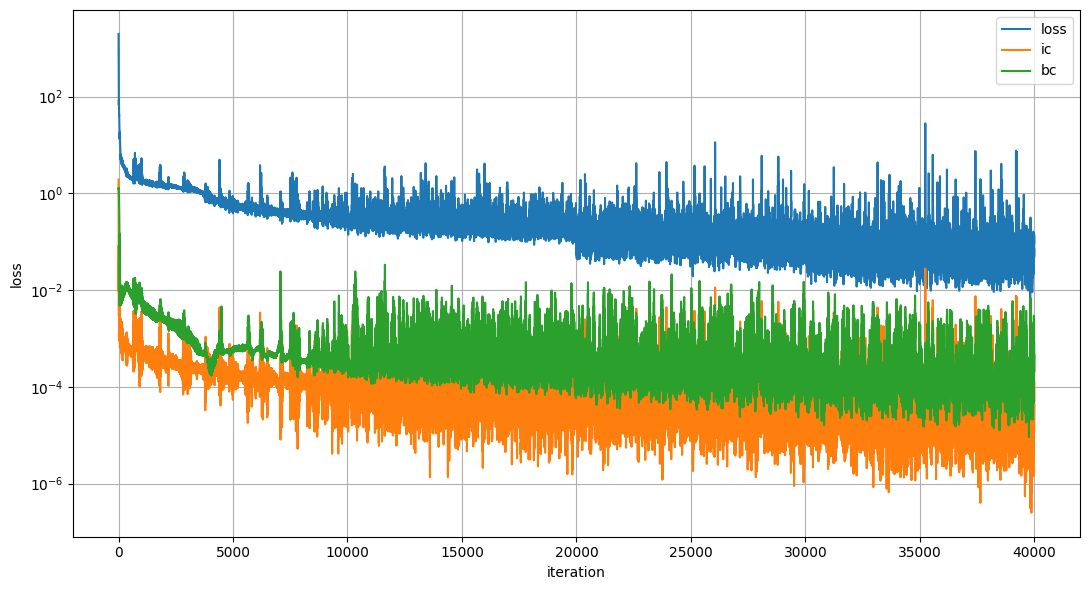

In [18]:
def plot_history(history):
    df = pd.DataFrame(history)

    keys = [
        "loss",
        "mass",
        "mom",
        "mom_in",
        "mom_mid",
        "mom_out",
        "energy",
        "ic",
        "bc",
    ]

    plt.figure(figsize=(11, 6))

    for key in keys:
        if key in df:
            plt.semilogy(df[key].to_numpy(), label=key)

    plt.xlabel("iteration")
    plt.ylabel("loss")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_history(history)

In [19]:
@torch.no_grad()
def validate(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.tensor(forcing.tau.copy(), device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z_in = torch.zeros_like(t)
    z_out = torch.ones_like(t)

    G_in, _, pi_in, _, _, _ = physics.fields(z_in, t)
    G_out, _, pi_out, _, _, _ = physics.fields(z_out, t)

    flow_in_pinn = case.A * case.rho_pc * case.w0 * G_in
    flow_out_pinn = case.A * case.rho_pc * case.w0 * G_out

    Q = torch.tensor(forcing.power.copy(), device=device, dtype=dtype).reshape(-1, 1)

    ntpc_pinn = (
        case.beta_pc
        / case.Cp_pc
        * Q
        / flow_in_pinn
    )

    model.train()

    return {
        "time": forcing.time,
        "flow_in_base": forcing.flow_in,
        "flow_out_base": forcing.flow_out,
        "ntpc_base": forcing.ntpc,
        "flow_in_pinn": flow_in_pinn.cpu().numpy().reshape(-1),
        "flow_out_pinn": flow_out_pinn.cpu().numpy().reshape(-1),
        "ntpc_pinn": ntpc_pinn.cpu().numpy().reshape(-1),
        "pi_in_pinn": pi_in.cpu().numpy().reshape(-1),
        "pi_out_pinn": pi_out.cpu().numpy().reshape(-1),
        "pi_in_target": np.full_like(forcing.time, case.dpi_star, dtype=float),
        "pi_out_target": np.zeros_like(forcing.time, dtype=float),
    }


val = validate(model, physics, case, forcing, device, dtype)

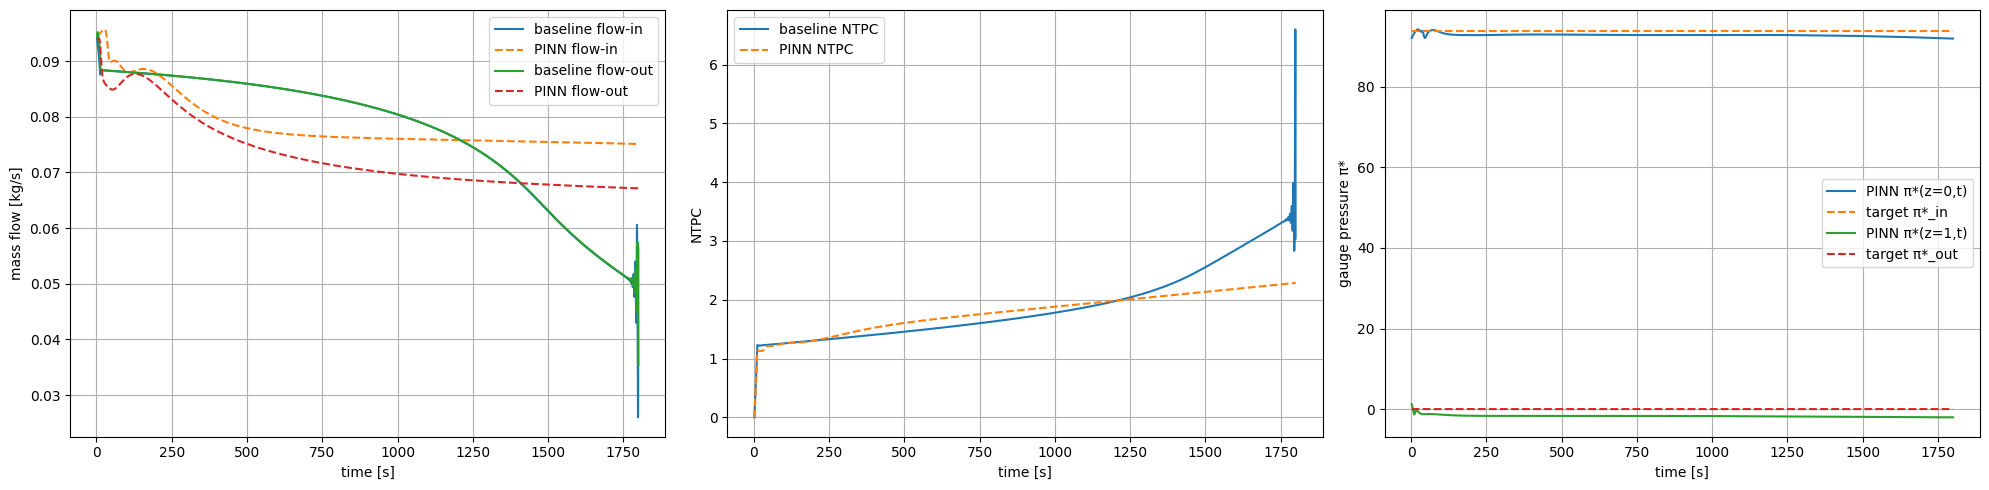

In [20]:
def plot_validation(val):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(val["time"], val["flow_in_base"], label="baseline flow-in")
    ax.plot(val["time"], val["flow_in_pinn"], "--", label="PINN flow-in")

    ax.plot(val["time"], val["flow_out_base"], label="baseline flow-out")
    ax.plot(val["time"], val["flow_out_pinn"], "--", label="PINN flow-out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(val["time"], val["ntpc_base"], label="baseline NTPC")
    ax.plot(val["time"], val["ntpc_pinn"], "--", label="PINN NTPC")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("NTPC")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(val["time"], val["pi_in_pinn"], label="PINN π*(z=0,t)")
    ax.plot(val["time"], val["pi_in_target"], "--", label="target π*_in")

    ax.plot(val["time"], val["pi_out_pinn"], label="PINN π*(z=1,t)")
    ax.plot(val["time"], val["pi_out_target"], "--", label="target π*_out")

    ax.set_xlabel("time [s]")
    ax.set_ylabel("gauge pressure π*")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()

plot_validation(val)

In [21]:
def rmse(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    return float(np.sqrt(np.mean((a - b) ** 2)))


print("RMSE flow-in :", rmse(val["flow_in_base"], val["flow_in_pinn"]))
print("RMSE flow-out:", rmse(val["flow_out_base"], val["flow_out_pinn"]))
print("RMSE NTPC    :", rmse(val["ntpc_base"], val["ntpc_pinn"]))

RMSE flow-in : 0.009925384641890687
RMSE flow-out: 0.009450455474840767
RMSE NTPC    : 0.38150915198405616


In [22]:
@torch.no_grad()
def boundary_field_stats(model, physics, case, forcing, device, dtype=torch.float32):
    model.eval()

    tau = torch.as_tensor(forcing.tau, device=device, dtype=dtype).reshape(-1, 1)
    t = tau * case.w0 / case.L

    z0 = torch.zeros_like(t)
    z1 = torch.ones_like(t)

    G0, h0, pi0, Ghat0, hhat0, Pihat0 = physics.fields(z0, t)
    G1, h1, pi1, Ghat1, hhat1, Pihat1 = physics.fields(z1, t)

    def stat(name, x):
        x = x.detach().cpu().numpy().reshape(-1)
        print(
            f"{name:14s}: "
            f"min={x.min(): .4e}, "
            f"mean={x.mean(): .4e}, "
            f"max={x.max(): .4e}, "
            f"std={x.std(): .4e}"
        )

    print("=== TARGETS ===")
    print(f"G0*        = {case.G0_star:.6e}")
    print(f"h_in*      = {case.h0_star:.6e}")
    print(f"pi_in*     = {case.dpi_star:.6e}")
    print(f"pi_out*    = 0")
    print()

    print("=== PHYSICAL SCALED FIELDS ===")
    stat("G(z=0)", G0)
    stat("G(z=1)", G1)
    stat("h(z=0)", h0)
    stat("h(z=1)", h1)
    stat("pi(z=0)", pi0)
    stat("pi(z=1)", pi1)

    print()
    print("=== RAW NETWORK OUTPUTS ===")
    stat("G_hat(z=0)", Ghat0)
    stat("G_hat(z=1)", Ghat1)
    stat("h_hat(z=0)", hhat0)
    stat("h_hat(z=1)", hhat1)
    stat("Pi_hat(z=0)", Pihat0)
    stat("Pi_hat(z=1)", Pihat1)

    model.train()


boundary_field_stats(model, physics, case, forcing, device, dtype)

=== TARGETS ===
G0*        = 2.698876e+00
h_in*      = -2.000000e+00
pi_in*     = 9.385098e+01
pi_out*    = 0

=== PHYSICAL SCALED FIELDS ===
G(z=0)        : min= 2.1493e+00, mean= 2.2292e+00, max= 2.7382e+00, std= 1.1453e-01
G(z=1)        : min= 1.9214e+00, mean= 2.0763e+00, max= 2.6923e+00, std= 1.6932e-01
h(z=0)        : min=-2.0810e+00, mean=-2.0335e+00, max=-1.9119e+00, std= 5.1700e-03
h(z=1)        : min=-2.0012e+00, mean=-8.7320e-01, max=-8.1350e-01, std= 7.0846e-02
pi(z=0)       : min= 9.1973e+01, mean= 9.2786e+01, max= 9.4257e+01, std= 2.5571e-01
pi(z=1)       : min=-2.0501e+00, mean=-1.7796e+00, max= 1.2136e+00, std= 1.7917e-01

=== RAW NETWORK OUTPUTS ===
G_hat(z=0)    : min= 7.9636e-01, mean= 8.2598e-01, max= 1.0146e+00, std= 4.2435e-02
G_hat(z=1)    : min= 7.1192e-01, mean= 7.6931e-01, max= 9.9755e-01, std= 6.2737e-02
h_hat(z=0)    : min=-1.0405e+00, mean=-1.0167e+00, max=-9.5597e-01, std= 2.5850e-03
h_hat(z=1)    : min=-1.0006e+00, mean=-4.3660e-01, max=-4.0675e-01, std= 

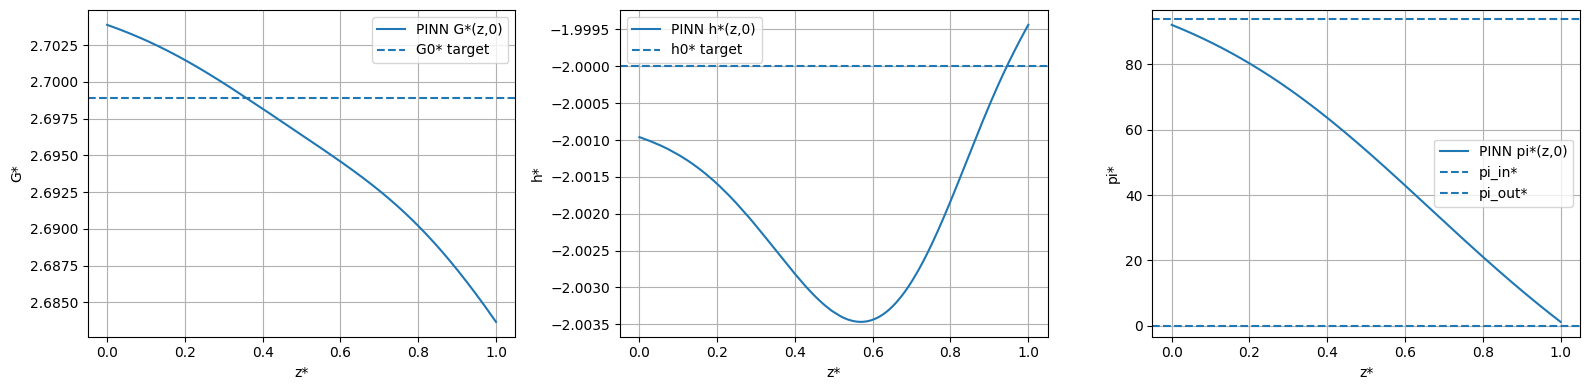

In [23]:
@torch.no_grad()
def plot_ic_profiles(model, physics, case, device, dtype=torch.float32):
    model.eval()

    z = torch.linspace(0, 1, 400, device=device, dtype=dtype).reshape(-1, 1)
    t = torch.zeros_like(z)

    G, h, pi, _, _, _ = physics.fields(z, t)

    z_np = z.cpu().numpy().reshape(-1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(z_np, G.cpu().numpy().reshape(-1), label="PINN G*(z,0)")
    axes[0].axhline(case.G0_star, linestyle="--", label="G0* target")
    axes[0].set_xlabel("z*")
    axes[0].set_ylabel("G*")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(z_np, h.cpu().numpy().reshape(-1), label="PINN h*(z,0)")
    axes[1].axhline(case.h0_star, linestyle="--", label="h0* target")
    axes[1].set_xlabel("z*")
    axes[1].set_ylabel("h*")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(z_np, pi.cpu().numpy().reshape(-1), label="PINN pi*(z,0)")
    axes[2].axhline(case.dpi_star, linestyle="--", label="pi_in*")
    axes[2].axhline(0.0, linestyle="--", label="pi_out*")
    axes[2].set_xlabel("z*")
    axes[2].set_ylabel("pi*")
    axes[2].grid(True)
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    model.train()


plot_ic_profiles(model, physics, case, device, dtype)

In [24]:
def normalized_error_report(history):
    last = history[-1]

    print("=== NORMALIZED ERROR REPORT ===")

    for key in [
        "ic_G",
        "ic_h",
        "bc_h_in",
        "bc_dp",
        "bc_pi_out",
        "mass",
        "mom",
        "energy",
    ]:
        if key in last:
            print(f"{key:12s}: RMS = {math.sqrt(last[key]):.6e}, MSE = {last[key]:.6e}")


normalized_error_report(history)

=== NORMALIZED ERROR REPORT ===


In [25]:
@torch.no_grad()
def eval_fields_on_grid(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, pi, _, _, _ = physics.fields(zz, tt)
    rho, chi_h = physics.eos25(h)

    out = {
        "z": z.cpu().numpy(),
        "t_star": t.cpu().numpy(),
        "time_s": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "G": G.cpu().numpy().reshape(n_z, n_t),
        "h": h.cpu().numpy().reshape(n_z, n_t),
        "pi": pi.cpu().numpy().reshape(n_z, n_t),
        "rho": rho.cpu().numpy().reshape(n_z, n_t),
        "chi_h": chi_h.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


grid = eval_fields_on_grid(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=201,
    n_t=300,
)

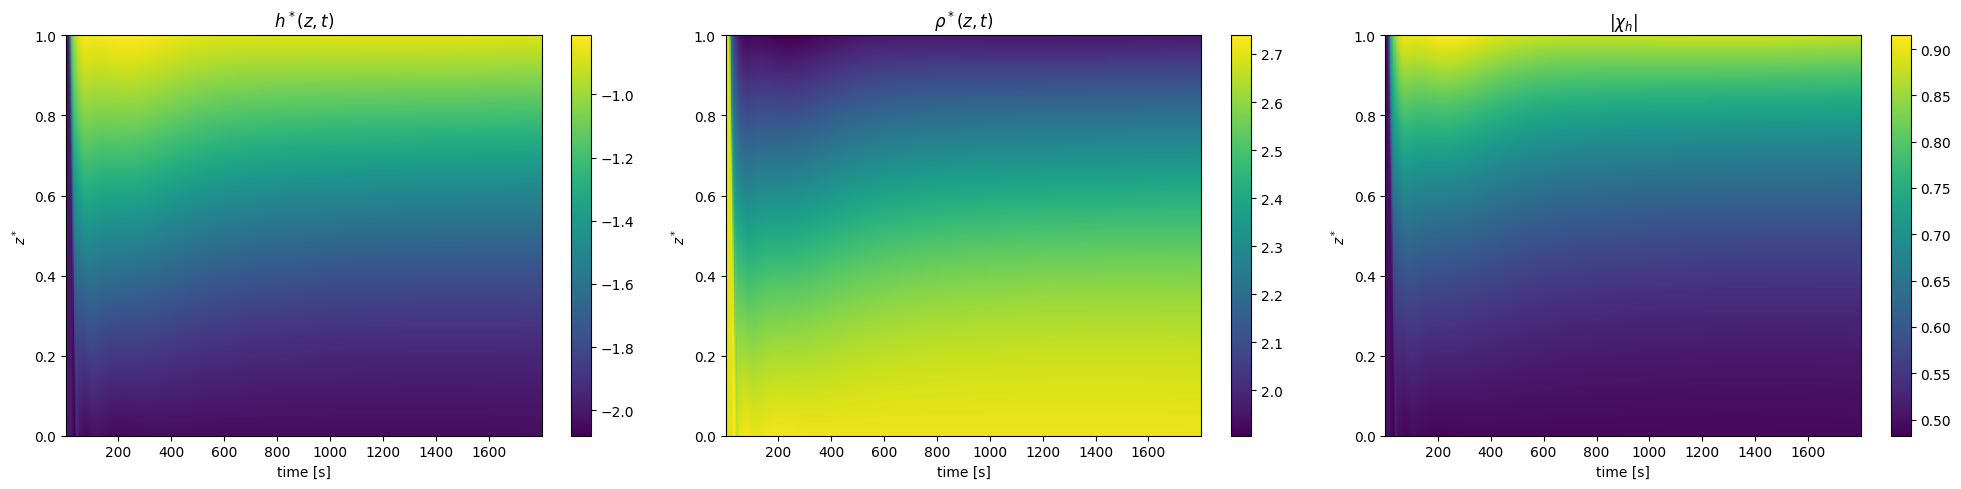

In [26]:
def plot_heatmaps(grid):
    z = grid["z"]
    time = grid["time_s"]

    fields = [
        ("h", r"$h^*(z,t)$"),
        ("rho", r"$\rho^*(z,t)$"),
        ("chi_h", r"$\chi_h=d\rho^*/dh^*$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, (key, title) in zip(axes, fields):
        data = grid[key]

        if key == "chi_h":
            data = np.abs(data)
            title = r"$|\chi_h|$"

        im = ax.imshow(
            data,
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


plot_heatmaps(grid)

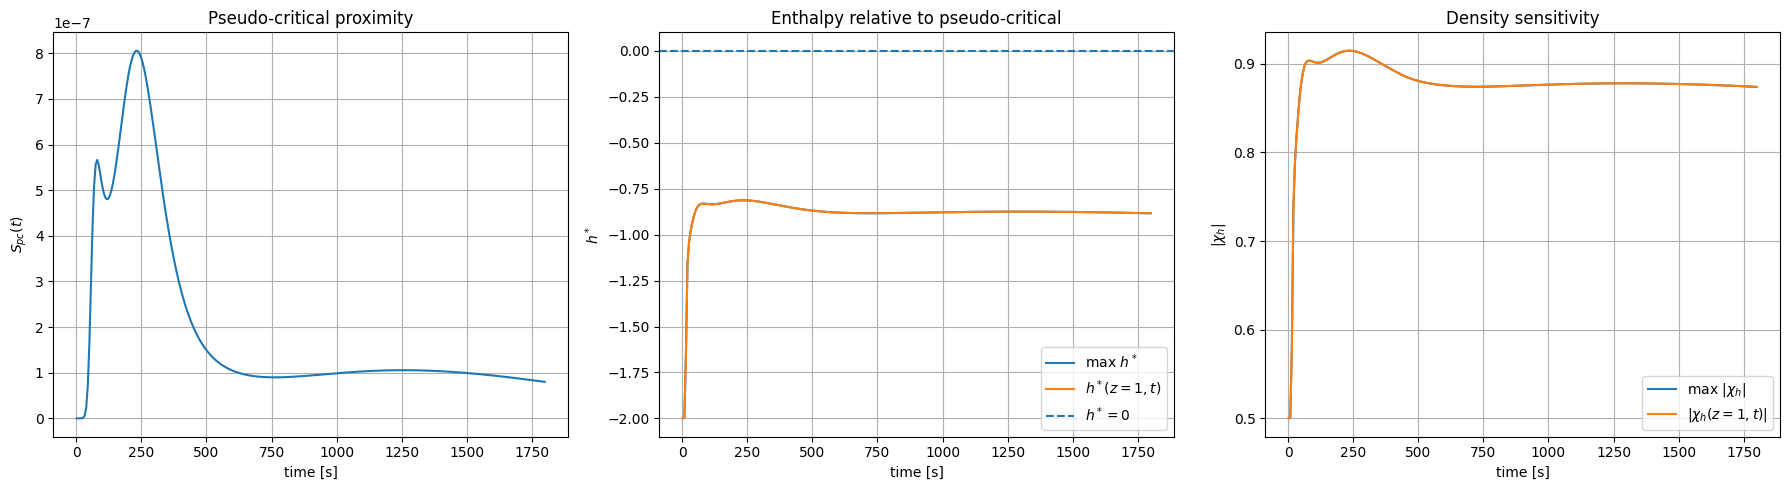

In [27]:
def pseudo_critical_indicator(grid, sigma_h=0.25):
    z = grid["z"]
    h = grid["h"]
    chi_h = grid["chi_h"]

    kernel = np.exp(-(h / sigma_h) ** 2)

    S_pc = np.trapezoid(kernel, z, axis=0)
    h_max = h.max(axis=0)
    h_out = h[-1, :]
    chi_max = np.max(np.abs(chi_h), axis=0)
    chi_out = np.abs(chi_h[-1, :])

    return {
        "time": grid["time_s"],
        "S_pc": S_pc,
        "h_max": h_max,
        "h_out": h_out,
        "chi_max": chi_max,
        "chi_out": chi_out,
    }


pc = pseudo_critical_indicator(grid, sigma_h=0.25)


def plot_pseudo_critical_indicator(pc):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(pc["time"], pc["S_pc"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$S_{pc}(t)$")
    ax.set_title("Pseudo-critical proximity")
    ax.grid(True)

    ax = axes[1]
    ax.plot(pc["time"], pc["h_max"], label=r"max $h^*$")
    ax.plot(pc["time"], pc["h_out"], label=r"$h^*(z=1,t)$")
    ax.axhline(0.0, linestyle="--", label=r"$h^*=0$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$h^*$")
    ax.set_title("Enthalpy relative to pseudo-critical")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(pc["time"], pc["chi_max"], label=r"max $|\chi_h|$")
    ax.plot(pc["time"], pc["chi_out"], label=r"$|\chi_h(z=1,t)|$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$|\chi_h|$")
    ax.set_title("Density sensitivity")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_pseudo_critical_indicator(pc)

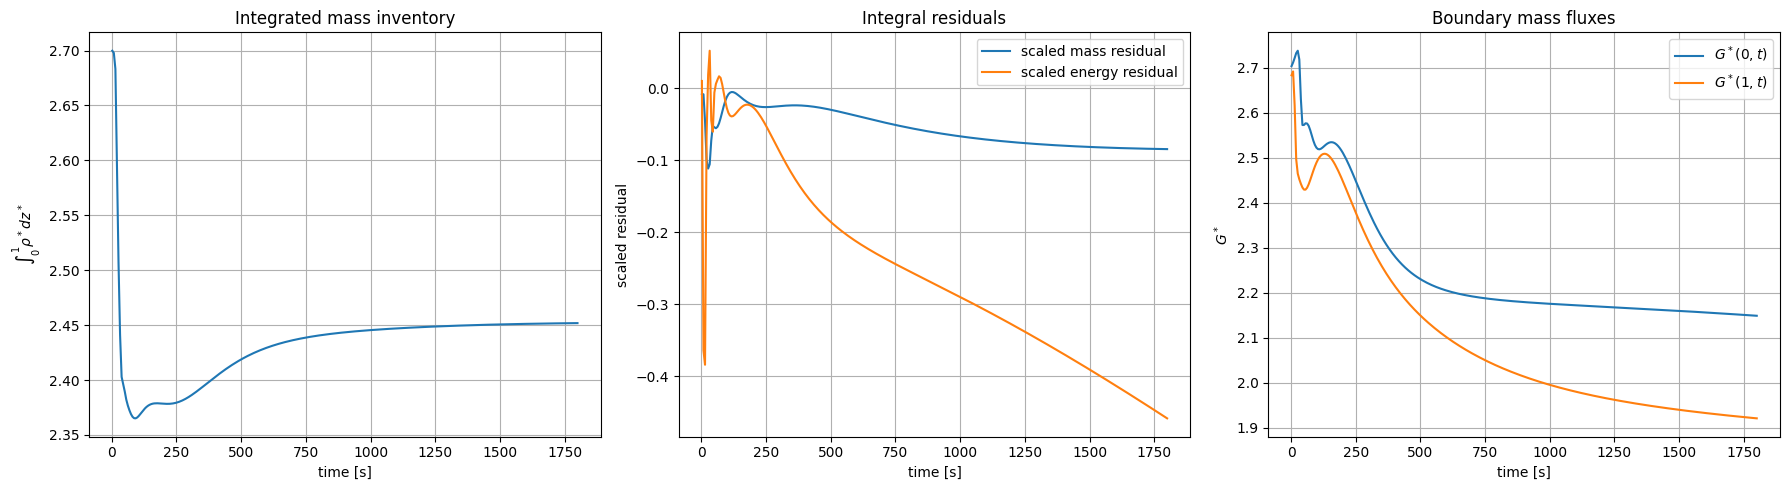

Integral mass residual RMS: 0.0615144
Integral energy residual RMS: 0.28688347


In [28]:
@torch.no_grad()
def integral_residuals(grid, physics, case, forcing, device, dtype=torch.float32):
    z = grid["z"]
    t_star = grid["t_star"]
    time = grid["time_s"]

    G = grid["G"]
    h = grid["h"]
    rho = grid["rho"]

    mass_int = np.trapezoid(rho, z, axis=0)
    energy_int = np.trapezoid(rho * h, z, axis=0)

    dmass_dt = np.gradient(mass_int, t_star)
    denergy_dt = np.gradient(energy_int, t_star)

    G_in = G[0, :]
    G_out = G[-1, :]

    Gh_in = G[0, :] * h[0, :]
    Gh_out = G[-1, :] * h[-1, :]

    t_tensor = torch.tensor(t_star.copy(), device=device, dtype=dtype).reshape(-1, 1)
    NQ = physics.NQ_prime(t_tensor).detach().cpu().numpy().reshape(-1)

    R_mass_int = dmass_dt + G_out - G_in
    R_energy_int = denergy_dt + Gh_out - Gh_in - NQ

    return pd.DataFrame({
        "time": time,
        "mass_int": mass_int,
        "energy_int": energy_int,
        "R_mass_int": R_mass_int,
        "R_energy_int": R_energy_int,
        "R_mass_int_scaled": R_mass_int / case.mass_scale,
        "R_energy_int_scaled": R_energy_int / case.energy_scale,
        "G_in": G_in,
        "G_out": G_out,
        "NQ": NQ,
    })


int_res = integral_residuals(grid, physics, case, forcing, device, dtype)


def plot_integral_residuals(int_res):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(int_res["time"], int_res["mass_int"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\int_0^1 \rho^* dz^*$")
    ax.set_title("Integrated mass inventory")
    ax.grid(True)

    ax = axes[1]
    ax.plot(int_res["time"], int_res["R_mass_int_scaled"], label="scaled mass residual")
    ax.plot(int_res["time"], int_res["R_energy_int_scaled"], label="scaled energy residual")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("scaled residual")
    ax.set_title("Integral residuals")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(int_res["time"], int_res["G_in"], label=r"$G^*(0,t)$")
    ax.plot(int_res["time"], int_res["G_out"], label=r"$G^*(1,t)$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$G^*$")
    ax.set_title("Boundary mass fluxes")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_integral_residuals(int_res)

print("Integral mass residual RMS:", np.sqrt(np.mean(int_res["R_mass_int_scaled"] ** 2)))
print("Integral energy residual RMS:", np.sqrt(np.mean(int_res["R_energy_int_scaled"] ** 2)))

In [29]:
def pressure_budget(model, physics, case, device, dtype=torch.float32, n_z=401, n_t=200):
    model.train()

    z_base = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype).reshape(-1, 1)
    t_vals = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    rows = []

    for t0 in t_vals:
        z = z_base.clone().detach().requires_grad_(True)
        t = torch.full_like(z, t0.item()).requires_grad_(True)

        G, h, pi, _, _, _ = physics.fields(z, t)
        rho, _ = physics.eos25(h)

        G_t = d(G, t)

        flux = G**2 / rho

        delta0 = delta_inlet(z, physics.alpha)
        delta1 = delta_outlet(z, physics.alpha)

        accel = torch.trapezoid(G_t.reshape(-1), z.reshape(-1))
        flux_jump = flux[-1, 0] - flux[0, 0]
        gravity = torch.trapezoid((rho / case.Fr).reshape(-1), z.reshape(-1))

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = physics.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        friction_dist = torch.trapezoid(
            (Lambda_dyn * signed_loss_flux).reshape(-1),
            z.reshape(-1),
        )

        # Match residuals_raw: anchor the local-loss density at the end faces
        # (rho[0] at inlet, rho[-1] at outlet) instead of using signed_loss_flux,
        # which carries the local rho(z) smeared by the Gaussian.
        loss_flux_num = (G * smooth_abs(G, eps=1e-6)).reshape(-1)  # G|G|

        local_in = torch.trapezoid(
            0.5 * case.kin * delta_inlet(z, physics.alpha).reshape(-1)
            * loss_flux_num / rho[0, 0],
            z.reshape(-1),
        )

        local_out = torch.trapezoid(
            0.5 * case.kout * delta_outlet(z, physics.alpha).reshape(-1)
            * loss_flux_num / rho[-1, 0],
            z.reshape(-1),
        )

        pressure_drop = pi[0, 0] - pi[-1, 0]

        rhs = accel + flux_jump + gravity + friction_dist + local_in + local_out
        residual = rhs - pressure_drop

        rows.append({
            "t_star": float(t0.detach().cpu()),
            "time": float(t0.detach().cpu()) * case.L / case.w0 + 2.0,
            "pressure_drop": float(pressure_drop.detach().cpu()),
            "accel": float(accel.detach().cpu()),
            "flux_jump": float(flux_jump.detach().cpu()),
            "gravity": float(gravity.detach().cpu()),
            "friction_dist": float(friction_dist.detach().cpu()),
            "local_in": float(local_in.detach().cpu()),
            "local_out": float(local_out.detach().cpu()),
            "rhs": float(rhs.detach().cpu()),
            "budget_residual": float(residual.detach().cpu()),
        })

    return pd.DataFrame(rows)


budget = pressure_budget(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=401,
    n_t=200,
)

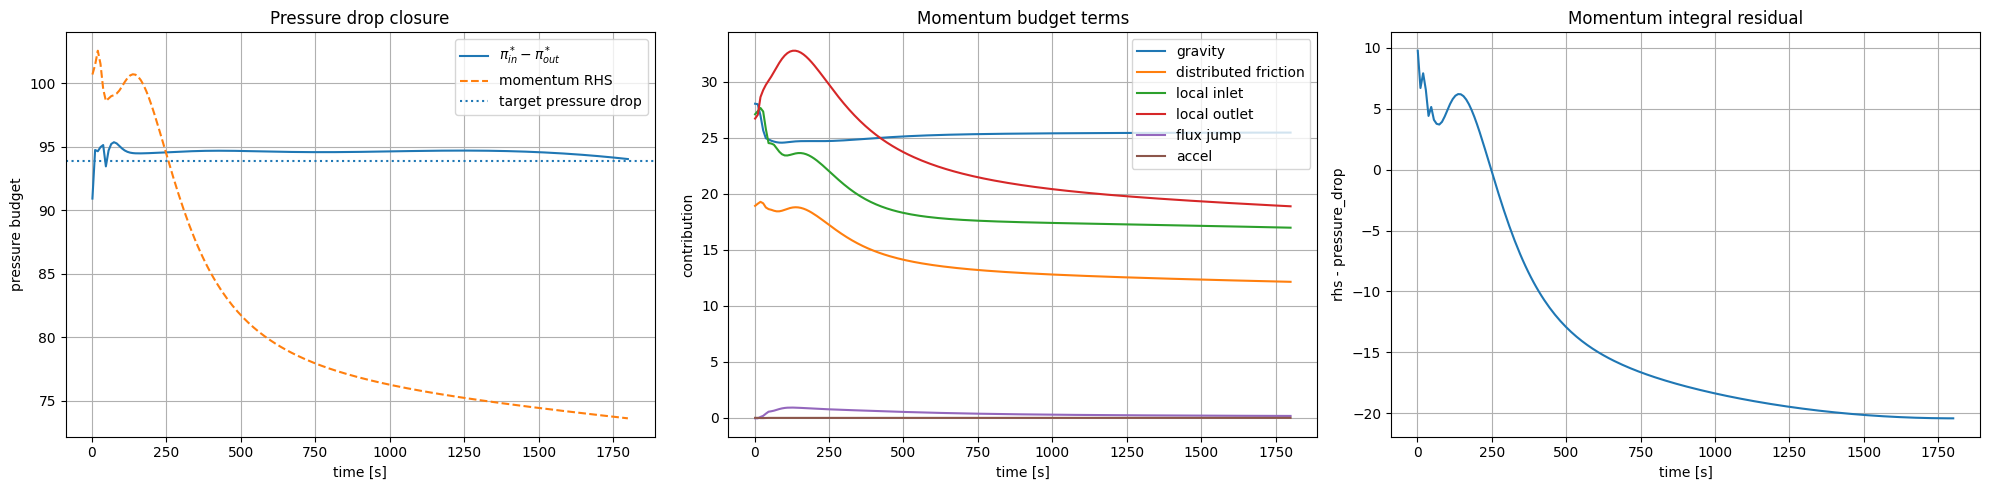

Pressure budget residual RMS: 16.202938811465245
Mean pressure drop: 94.56405055999755
Target pressure drop: 93.85097958770776


In [30]:
def plot_pressure_budget(budget):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    ax = axes[0]
    ax.plot(budget["time"], budget["pressure_drop"], label=r"$\pi_{in}^*-\pi_{out}^*$")
    ax.plot(budget["time"], budget["rhs"], "--", label="momentum RHS")
    ax.axhline(case.dpi_star, linestyle=":", label="target pressure drop")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("pressure budget")
    ax.set_title("Pressure drop closure")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(budget["time"], budget["gravity"], label="gravity")
    ax.plot(budget["time"], budget["friction_dist"], label="distributed friction")
    ax.plot(budget["time"], budget["local_in"], label="local inlet")
    ax.plot(budget["time"], budget["local_out"], label="local outlet")
    ax.plot(budget["time"], budget["flux_jump"], label="flux jump")
    ax.plot(budget["time"], budget["accel"], label="accel")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("contribution")
    ax.set_title("Momentum budget terms")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(budget["time"], budget["budget_residual"])
    ax.set_xlabel("time [s]")
    ax.set_ylabel("rhs - pressure_drop")
    ax.set_title("Momentum integral residual")
    ax.grid(True)

    plt.tight_layout()
    plt.show()


plot_pressure_budget(budget)

print("Pressure budget residual RMS:", np.sqrt(np.mean(budget["budget_residual"] ** 2)))
print("Mean pressure drop:", budget["pressure_drop"].mean())
print("Target pressure drop:", case.dpi_star)

In [31]:
def summarize_early_late(grid, int_res, budget, split_time=1100.0):
    time = grid["time_s"]

    early = time < split_time
    late = time >= split_time

    def mean_range(name, arr):
        return {
            f"{name}_early_mean": float(np.mean(arr[early])),
            f"{name}_late_mean": float(np.mean(arr[late])),
            f"{name}_early_min": float(np.min(arr[early])),
            f"{name}_late_min": float(np.min(arr[late])),
            f"{name}_early_max": float(np.max(arr[early])),
            f"{name}_late_max": float(np.max(arr[late])),
        }

    pc = pseudo_critical_indicator(grid)

    rows = {}
    rows.update(mean_range("S_pc", pc["S_pc"]))
    rows.update(mean_range("h_out", pc["h_out"]))
    rows.update(mean_range("chi_max", pc["chi_max"]))

    b_early = budget["time"] < split_time
    b_late = budget["time"] >= split_time

    for col in [
        "pressure_drop",
        "gravity",
        "friction_dist",
        "local_in",
        "local_out",
        "accel",
        "flux_jump",
        "budget_residual",
    ]:
        rows[f"{col}_early_mean"] = float(budget.loc[b_early, col].mean())
        rows[f"{col}_late_mean"] = float(budget.loc[b_late, col].mean())

    i_early = int_res["time"] < split_time
    i_late = int_res["time"] >= split_time

    rows["R_mass_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_mass_int_scaled"] ** 2)))
    rows["R_mass_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_mass_int_scaled"] ** 2)))

    rows["R_energy_int_early_rms"] = float(np.sqrt(np.mean(int_res.loc[i_early, "R_energy_int_scaled"] ** 2)))
    rows["R_energy_int_late_rms"] = float(np.sqrt(np.mean(int_res.loc[i_late, "R_energy_int_scaled"] ** 2)))

    return pd.DataFrame.from_dict(rows, orient="index", columns=["value"])


summary_late = summarize_early_late(grid, int_res, budget, split_time=1100.0)
summary_late.to_csv("summary_late.csv")

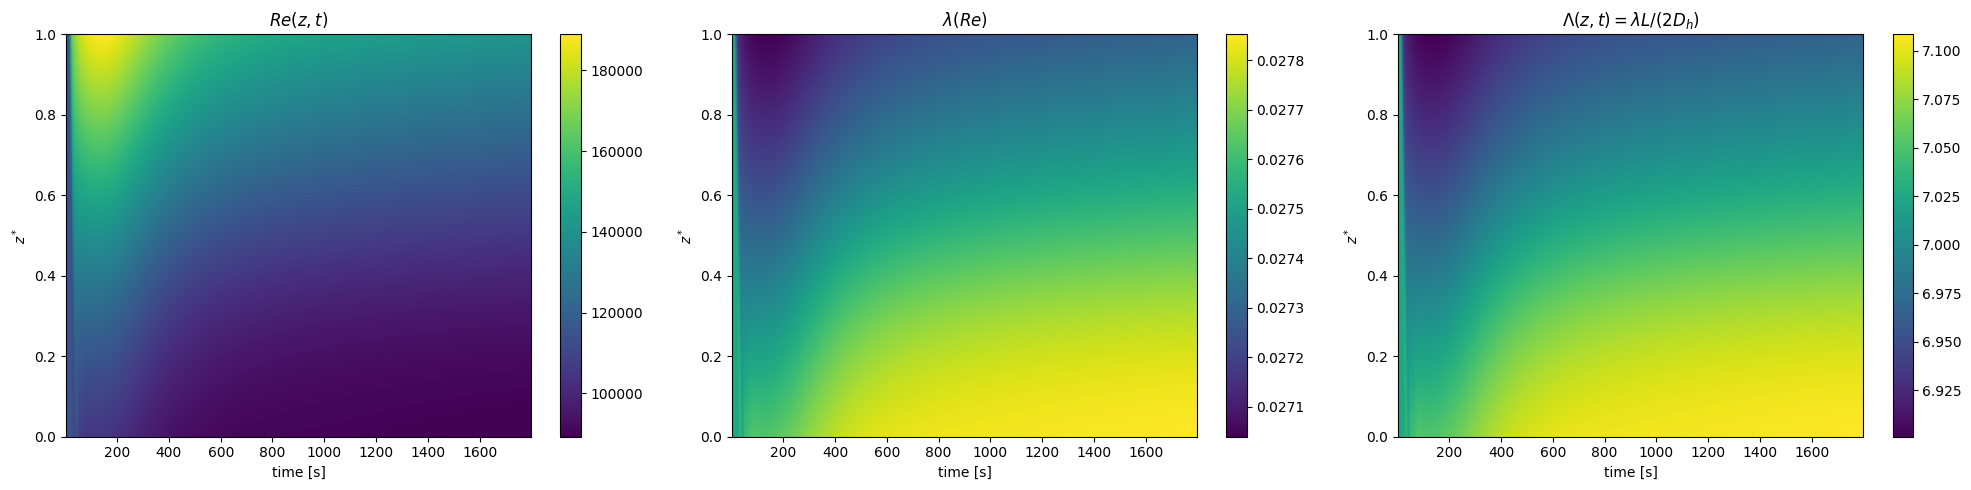

In [32]:
@torch.no_grad()
def friction_diagnostics(model, physics, case, device, dtype=torch.float32, n_z=201, n_t=300):
    model.eval()

    z = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
    t = torch.linspace(0.0, case.t_end_star, n_t, device=device, dtype=dtype)

    Z, T = torch.meshgrid(z, t, indexing="ij")

    zz = Z.reshape(-1, 1)
    tt = T.reshape(-1, 1)

    G, h, _, _, _, _ = physics.fields(zz, tt)
    rho, _ = physics.eos25(h)

    Lambda_dyn, _, Re, lambda_darcy = physics.distributed_friction(G, h, rho)

    out = {
        "z": z.cpu().numpy(),
        "time": (t.cpu().numpy() * case.L / case.w0) + 2.0,
        "Re": Re.cpu().numpy().reshape(n_z, n_t),
        "lambda": lambda_darcy.cpu().numpy().reshape(n_z, n_t),
        "Lambda": Lambda_dyn.cpu().numpy().reshape(n_z, n_t),
    }

    model.train()
    return out


def plot_friction_diagnostics(fr):
    z = fr["z"]
    time = fr["time"]

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    for ax, key, title in zip(
        axes,
        ["Re", "lambda", "Lambda"],
        [r"$Re(z,t)$", r"$\lambda(Re)$", r"$\Lambda(z,t)=\lambda L/(2D_h)$"],
    ):
        im = ax.imshow(
            fr[key],
            origin="lower",
            aspect="auto",
            extent=[time.min(), time.max(), z.min(), z.max()],
        )

        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.set_ylabel(r"$z^*$")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


fr = friction_diagnostics(model, physics, case, device, dtype)
plot_friction_diagnostics(fr)

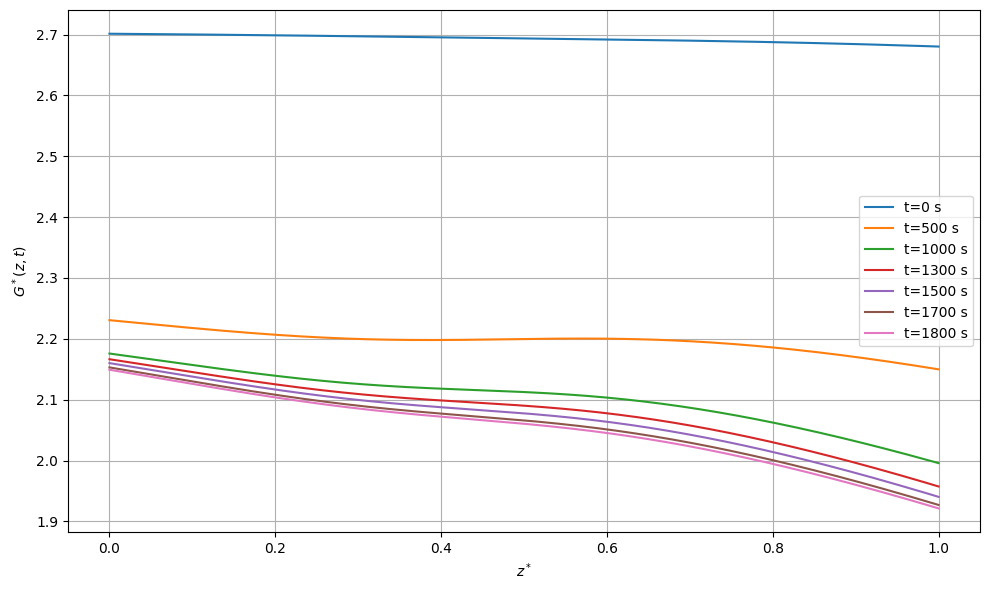

In [33]:
@torch.no_grad()
def plot_G_profiles(model, physics, case, times_s, device, dtype=torch.float32):
    model.eval()

    z = torch.linspace(0.0, 1.0, 400, device=device, dtype=dtype).reshape(-1, 1)

    plt.figure(figsize=(10, 6))

    for ts in times_s:
        t_star = (ts - 2.0) * case.w0 / case.L
        t = torch.full_like(z, t_star)

        G, h, pi, _, _, _ = physics.fields(z, t)

        plt.plot(
            z.cpu().numpy().reshape(-1),
            G.cpu().numpy().reshape(-1),
            label=f"t={ts:.0f} s",
        )

    plt.xlabel(r"$z^*$")
    plt.ylabel(r"$G^*(z,t)$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    model.train()


plot_G_profiles(
    model=model,
    physics=physics,
    case=case,
    times_s=[0, 500, 1000, 1300, 1500, 1700, 1800],
    device=device,
    dtype=dtype,
)

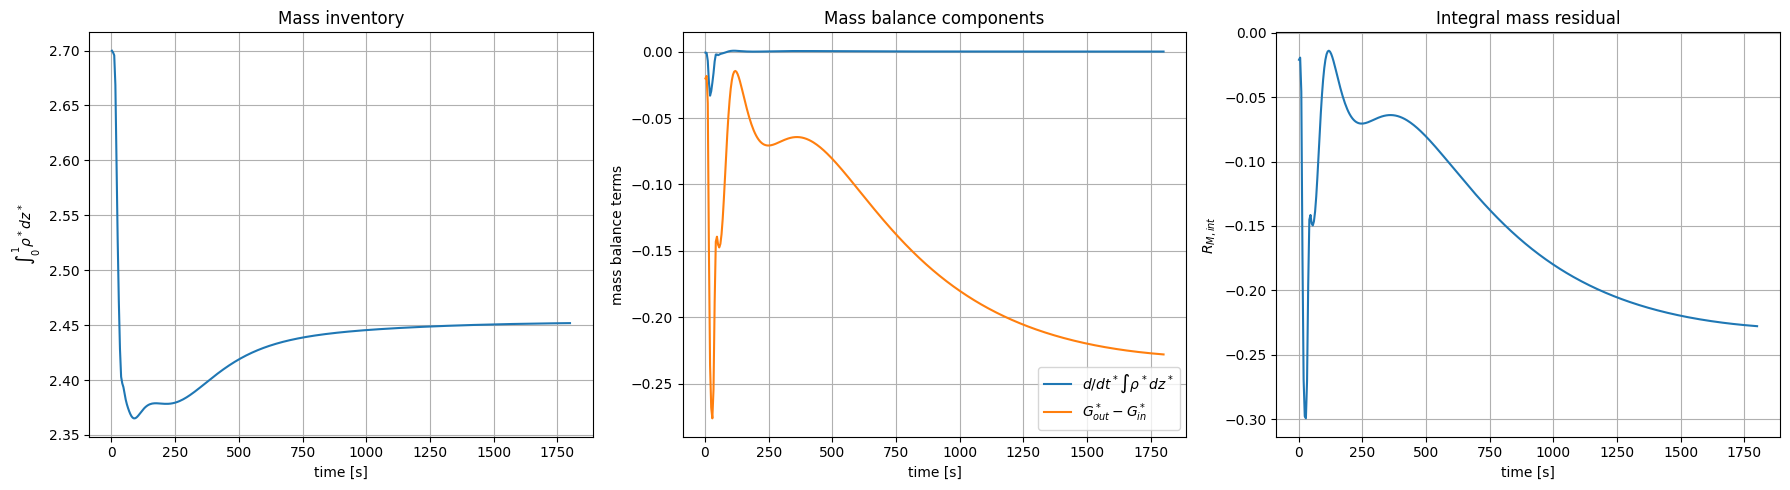

Integral mass RMS: 0.16604328


In [34]:
@torch.no_grad()
def plot_mass_balance_components(grid):
    z = grid["z"]
    t = grid["t_star"]
    time = grid["time_s"]

    rho = grid["rho"]
    G = grid["G"]

    mass_inventory = np.trapezoid(rho, z, axis=0)
    dM_dt = np.gradient(mass_inventory, t)

    G_in = G[0, :]
    G_out = G[-1, :]

    R = dM_dt + G_out - G_in

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    ax = axes[0]
    ax.plot(time, mass_inventory)
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\int_0^1 \rho^* dz^*$")
    ax.set_title("Mass inventory")
    ax.grid(True)

    ax = axes[1]
    ax.plot(time, dM_dt, label=r"$d/dt^* \int \rho^* dz^*$")
    ax.plot(time, G_out - G_in, label=r"$G^*_{out}-G^*_{in}$")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass balance terms")
    ax.set_title("Mass balance components")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(time, R)
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$R_{M,int}$")
    ax.set_title("Integral mass residual")
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    print("Integral mass RMS:", np.sqrt(np.mean(R**2)))


grid = eval_fields_on_grid(
    model=model,
    physics=physics,
    case=case,
    device=device,
    dtype=dtype,
    n_z=201,
    n_t=400,
)

plot_mass_balance_components(grid)

In [35]:
@torch.no_grad()
def observe_pinn_extended(
    model,
    physics,
    case,
    forcing,
    device,
    dtype=torch.float32,
    extra_time_s=1000.0,
    n_t=1000,
):
    model.eval()

    time0 = forcing.time[0]
    time1 = forcing.time[-1] + extra_time_s

    time = np.linspace(time0, time1, n_t)
    tau = time - time0

    t_star_np = tau * case.w0 / case.L
    t = torch.tensor(t_star_np.copy(), device=device, dtype=dtype).reshape(-1, 1)

    z_in = torch.zeros_like(t)
    z_out = torch.ones_like(t)

    G_in, h_in, pi_in, _, _, _ = physics.fields(z_in, t)
    G_out, h_out, pi_out, _, _, _ = physics.fields(z_out, t)

    flow_in = case.A * case.rho_pc * case.w0 * G_in
    flow_out = case.A * case.rho_pc * case.w0 * G_out

    # np.interp вне диапазона держит последнее значение power
    Q_np = np.interp(tau, forcing.tau, forcing.power)
    Q = torch.tensor(Q_np.copy(), device=device, dtype=dtype).reshape(-1, 1)

    ntpc = (
        case.beta_pc
        / case.Cp_pc
        * Q
        / flow_in
    )

    model.train()

    return {
        "time": time,
        "flow_in": flow_in.cpu().numpy().reshape(-1),
        "flow_out": flow_out.cpu().numpy().reshape(-1),
        "ntpc": ntpc.cpu().numpy().reshape(-1),
        "h_out": h_out.cpu().numpy().reshape(-1),
        "pi_in": pi_in.cpu().numpy().reshape(-1),
        "pi_out": pi_out.cpu().numpy().reshape(-1),
        "original_time_end": forcing.time[-1],
    }


obs = observe_pinn_extended(
    model=model,
    physics=physics,
    case=case,
    forcing=forcing,
    device=device,
    dtype=dtype,
    extra_time_s=1000.0,
    n_t=1200,
)

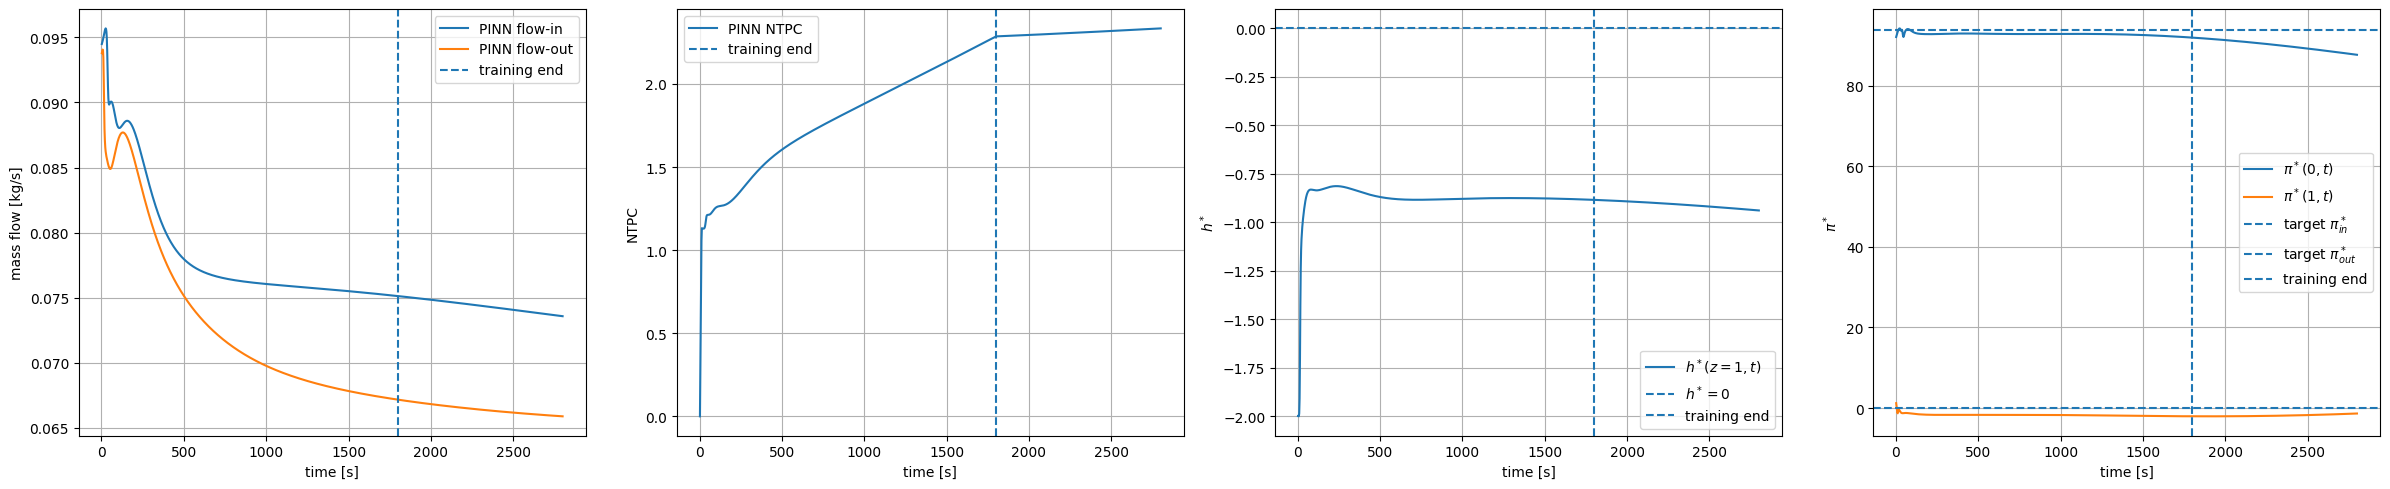

In [36]:
def plot_extended_observation(obs):
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    t_end = obs["original_time_end"]

    ax = axes[0]
    ax.plot(obs["time"], obs["flow_in"], label="PINN flow-in")
    ax.plot(obs["time"], obs["flow_out"], label="PINN flow-out")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("mass flow [kg/s]")
    ax.grid(True)
    ax.legend()

    ax = axes[1]
    ax.plot(obs["time"], obs["ntpc"], label="PINN NTPC")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel("NTPC")
    ax.grid(True)
    ax.legend()

    ax = axes[2]
    ax.plot(obs["time"], obs["h_out"], label=r"$h^*(z=1,t)$")
    ax.axhline(0.0, linestyle="--", label=r"$h^*=0$")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$h^*$")
    ax.grid(True)
    ax.legend()

    ax = axes[3]
    ax.plot(obs["time"], obs["pi_in"], label=r"$\pi^*(0,t)$")
    ax.plot(obs["time"], obs["pi_out"], label=r"$\pi^*(1,t)$")
    ax.axhline(case.dpi_star, linestyle="--", label=r"target $\pi^*_{in}$")
    ax.axhline(0.0, linestyle="--", label=r"target $\pi^*_{out}$")
    ax.axvline(t_end, linestyle="--", label="training end")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\pi^*$")
    ax.grid(True)
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_extended_observation(obs)

keeper        RMS all     RMS late   (late = last 11%)
mom         1.662e-01    2.133e-01
energy      2.856e-01    4.373e-01
mass        6.170e-02    8.378e-02


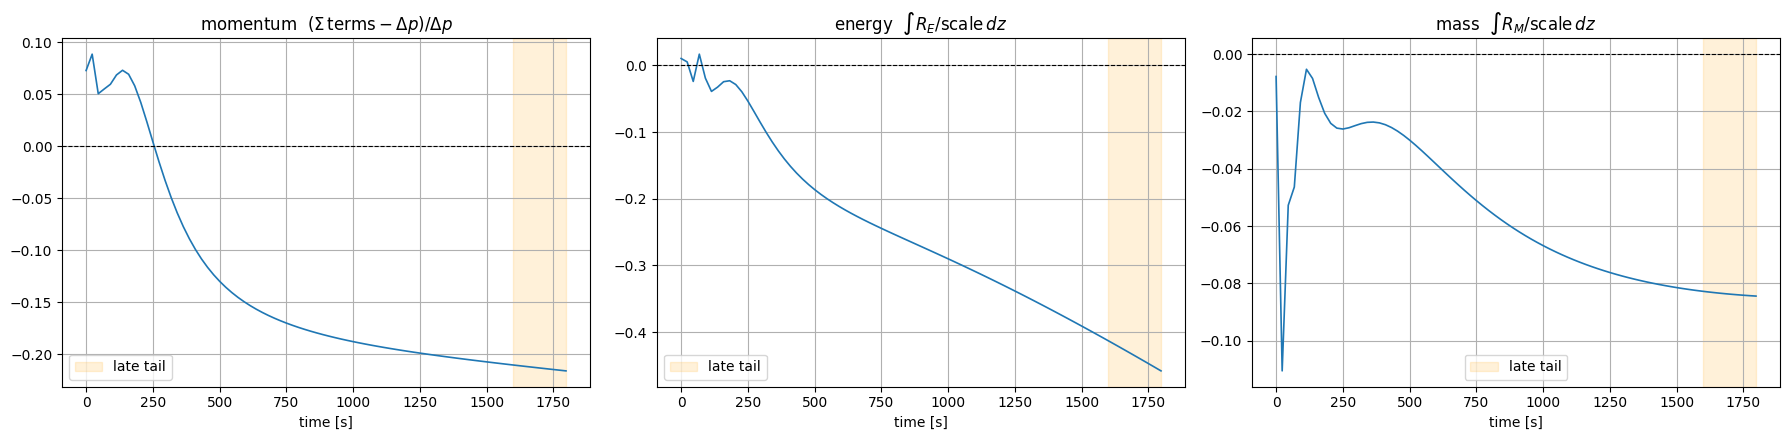

In [37]:
# === Per-keeper diagnostic (cheap, no retraining) ==========================
# For the CURRENT model, plot the SIGNED integral each keeper drives to zero,
# vs time. Shows whether each conservation identity is violated and WHERE
# (early vs the late tail where the flow drop lives). mean(profile**2) should
# match the logged mom_int / energy_int / mass_int. Run after any training (or
# even untrained, to see the starting imbalance).
def keeper_diagnostic(physics, case, n_t=80, tail_frac=0.11):
    prof = physics.keeper_time_profiles(n_t=n_t)
    t = np.asarray(prof["t_sec"])
    te = t.max()
    late = t >= (1.0 - tail_frac) * te

    panels = [
        ("mom",    r"momentum  $(\Sigma\,\mathrm{terms}-\Delta p)/\Delta p$"),
        ("energy", r"energy  $\int R_E/\mathrm{scale}\,dz$"),
        ("mass",   r"mass  $\int R_M/\mathrm{scale}\,dz$"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    print(f"{'keeper':8s} {'RMS all':>12s} {'RMS late':>12s}   (late = last {tail_frac:.0%})")
    for ax, (key, title) in zip(axes, panels):
        y = np.asarray(prof[key])
        rms_all = float(np.sqrt(np.mean(y ** 2)))
        rms_late = float(np.sqrt(np.mean(y[late] ** 2)))
        print(f"{key:8s} {rms_all:12.3e} {rms_late:12.3e}")
        ax.plot(t, y, lw=1.2)
        ax.axhline(0.0, ls="--", c="k", lw=0.8)
        ax.axvspan((1.0 - tail_frac) * te, te, color="orange", alpha=0.15,
                   label="late tail")
        ax.set_title(title)
        ax.set_xlabel("time [s]")
        ax.grid(True)
        ax.legend()
    plt.tight_layout()
    plt.show()
    return prof


_ = keeper_diagnostic(physics, case)


In [38]:
# === Keeper ablation (EXPENSIVE -- this is the part you run) ===============
# Trains a FRESH model per config from an IDENTICAL seeded init, toggling each
# integral keeper on/off, then reports late-time NTPC + flow-out vs baseline and
# each keeper's late residual. Isolates what each keeper buys. Does NOT touch the
# global model/trainer used by the other cells.
#   cost ~ len(ABLATIONS) * N_STEPS steps  (~0.7 s/step CPU -> budget accordingly)
from dataclasses import replace

N_STEPS = 1500       # <-- knob. raise for sharper NTPC separation; lower to scout.
ABL_SEED = 0         # identical init across configs isolates the keeper effect
TAIL_FRAC = 0.11

ABLATIONS = {
    "full":      dict(mom_integral=20.0, energy_integral=20.0, mass_integral=20.0),
    "no_mom":    dict(mom_integral=0.0,  energy_integral=20.0, mass_integral=20.0),
    "no_energy": dict(mom_integral=20.0, energy_integral=0.0,  mass_integral=20.0),
    "no_mass":   dict(mom_integral=20.0, energy_integral=20.0, mass_integral=0.0),
    "none":      dict(mom_integral=0.0,  energy_integral=0.0,  mass_integral=0.0),
}


def _build_model():
    torch.manual_seed(ABL_SEED)
    return SmoothPINN(
        t_end_star=case.t_end_star, width=128, depth=6, activation="tanh",
    ).to(device=device, dtype=dtype)


def _late_metrics(m, ph, tail_frac=TAIL_FRAC):
    val = validate(m, ph, case, forcing, device, dtype)
    t = np.asarray(val["time"]); te = t.max()
    late = t >= (1.0 - tail_frac) * te

    prof = ph.keeper_time_profiles(n_t=60)
    tp = np.asarray(prof["t_sec"]); lp = tp >= (1.0 - tail_frac) * tp.max()
    def lrms(k):
        a = np.asarray(prof[k]); return float(np.sqrt(np.mean(a[lp] ** 2)))

    return {
        "ntpc_pinn_late":    float(np.mean(val["ntpc_pinn"][late])),
        "ntpc_base_late":    float(np.mean(val["ntpc_base"][late])),
        "flowout_pinn_late": float(np.mean(val["flow_out_pinn"][late])),
        "flowout_base_late": float(np.mean(val["flow_out_base"][late])),
        "mom_late":  lrms("mom"),
        "energy_late": lrms("energy"),
        "mass_late": lrms("mass"),
    }


def run_ablation(n_steps=N_STEPS):
    rows = {}
    for name, ov in ABLATIONS.items():
        m = _build_model()
        ph = Physics(model=m, eos=eos, mu_spline=mu_spline, case=case,
                     forcing=forcing, alpha=0.02)
        smp = Sampler(case=case, device=device, dtype=dtype, alpha=0.02)
        tr = Trainer(model=m, physics=ph, sampler=smp,
                     weights=replace(weights, **ov), lr=3e-5)
        for _ in range(n_steps):
            tr.step(1.0)  # fixed eps for the ablation
        rows[name] = _late_metrics(m, ph)
        r = rows[name]
        print(f"[{name:9s}] NTPC_late={r['ntpc_pinn_late']:6.2f} "
              f"(base {r['ntpc_base_late']:.2f})  "
              f"flowout_late={r['flowout_pinn_late']:.4f} "
              f"(base {r['flowout_base_late']:.4f})  "
              f"mom={r['mom_late']:.2e} en={r['energy_late']:.2e} "
              f"mass={r['mass_late']:.2e}")
    return rows


def print_ablation_table(rows):
    base = next(iter(rows.values()))
    print(f"\n{'config':10s} {'NTPC_late':>10s} {'flowout_late':>13s} "
          f"{'mom_late':>10s} {'energy_late':>12s} {'mass_late':>10s}")
    print(f"{'baseline':10s} {base['ntpc_base_late']:10.2f} "
          f"{base['flowout_base_late']:13.4f} {'-':>10s} {'-':>12s} {'-':>10s}")
    for name, r in rows.items():
        print(f"{name:10s} {r['ntpc_pinn_late']:10.2f} "
              f"{r['flowout_pinn_late']:13.4f} {r['mom_late']:10.2e} "
              f"{r['energy_late']:12.2e} {r['mass_late']:10.2e}")


# ablation_rows = run_ablation()        # <-- UNCOMMENT to run (expensive)
# print_ablation_table(ablation_rows)


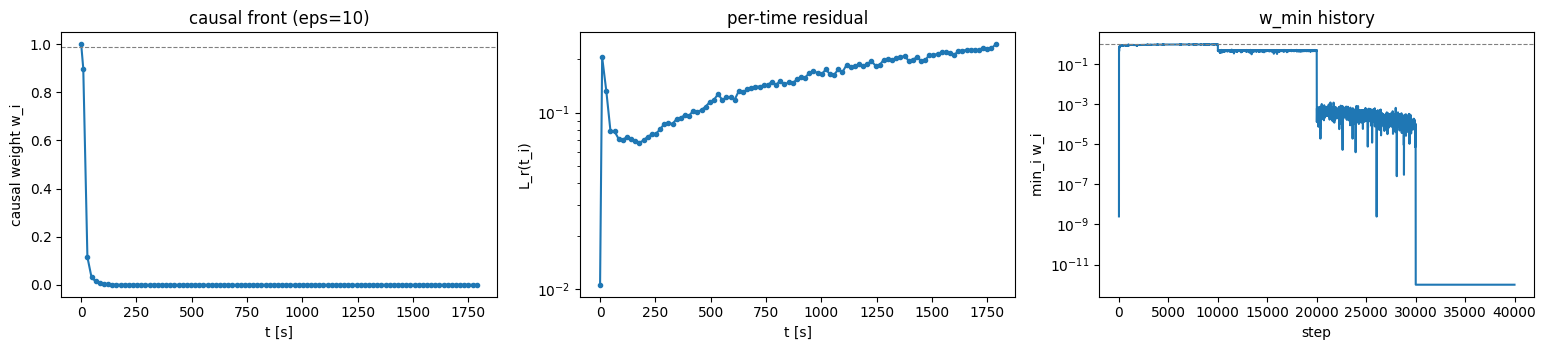

min w_i = 0.0000   max L_r = 2.435e-01


In [39]:
# === Causal-front diagnostic (cheap, no retraining) =======================
# w_i vs time shows how far the causal front has advanced (should reach t_end
# when converged); L_r(t_i) is the per-time residual; w_min history (if passed)
# tracks convergence across steps. Uses the last eps in the schedule.
def causal_front_diagnostic(physics, sampler, weights, eps, history=None):
    prof = physics.causal_weight_profile(sampler, weights, eps)
    t = np.asarray(prof["t_sec"])
    w = np.asarray(prof["w"])
    Lr = np.asarray(prof["Lr"])

    ncol = 2 if history is None else 3
    fig, ax = plt.subplots(1, ncol, figsize=(5.2 * ncol, 3.6))

    ax[0].plot(t, w, marker=".")
    ax[0].axhline(0.99, ls="--", c="grey", lw=0.8)
    ax[0].set_xlabel("t [s]")
    ax[0].set_ylabel("causal weight w_i")
    ax[0].set_title(f"causal front (eps={eps:g})")
    ax[0].set_ylim(-0.05, 1.05)

    ax[1].semilogy(t, np.maximum(Lr, 1e-12), marker=".")
    ax[1].set_xlabel("t [s]")
    ax[1].set_ylabel("L_r(t_i)")
    ax[1].set_title("per-time residual")

    if history is not None:
        wm = np.asarray([h.get("w_min", np.nan) for h in history])
        ax[2].semilogy(np.maximum(wm, 1e-12))
        ax[2].axhline(0.99, ls="--", c="grey", lw=0.8)
        ax[2].set_xlabel("step")
        ax[2].set_ylabel("min_i w_i")
        ax[2].set_title("w_min history")

    plt.tight_layout()
    plt.show()
    print(f"min w_i = {w.min():.4f}   max L_r = {Lr.max():.3e}")
    return prof


# run AFTER training:
_ = causal_front_diagnostic(physics, sampler, weights, eps_schedule[-1], history)
